In [203]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plot

In [204]:
df=pd.read_csv('loan.csv.zip')

C:\Users\syed altamash\AppData\Local\Temp\ipykernel_7996\1264764080.py:1: DtypeWarning: Columns (0: desc, 1: verification_status_joint) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('loan.csv.zip')


In [205]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  str    
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  str    
 9   sub_grade                    887379 non-null  str    
 10  emp_title                    835917 non-null  str    
 11  emp_length                   842554 non-null  str    
 12  home_ownership               887379 non-null  str    
 13  annual_inc

## Selecting importants columns

In [206]:
df=df[[
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_title",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "issue_d",
    "loan_status",
    "purpose",
    "title",
    "dti",
    "delinq_2yrs",
    "earliest_cr_line",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "out_prncp",
    "total_pymnt",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "collections_12_mths_ex_med",
    "acc_now_delinq",
    "tot_coll_amt",
    "tot_cur_bal",
    "total_bal_il",
    "max_bal_bc",
    "total_rev_hi_lim"
]]

In [207]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 41 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   887379 non-null  float64
 1   funded_amnt                 887379 non-null  float64
 2   term                        887379 non-null  str    
 3   int_rate                    887379 non-null  float64
 4   installment                 887379 non-null  float64
 5   grade                       887379 non-null  str    
 6   sub_grade                   887379 non-null  str    
 7   emp_title                   835917 non-null  str    
 8   emp_length                  842554 non-null  str    
 9   home_ownership              887379 non-null  str    
 10  annual_inc                  887375 non-null  float64
 11  verification_status         887379 non-null  str    
 12  issue_d                     887379 non-null  str    
 13  loan_status              

In [208]:
df.isnull().sum()

loan_amnt                          0
funded_amnt                        0
term                               0
int_rate                           0
installment                        0
grade                              0
sub_grade                          0
emp_title                      51462
emp_length                     44825
home_ownership                     0
annual_inc                         4
verification_status                0
issue_d                            0
loan_status                        0
purpose                            0
title                            153
dti                                0
delinq_2yrs                       29
earliest_cr_line                  29
inq_last_6mths                    29
open_acc                          29
pub_rec                           29
revol_bal                          0
revol_util                       502
total_acc                         29
out_prncp                          0
total_pymnt                        0
t

### total_bal_il,max_bal_bc have almost null values

In [209]:
df.drop(columns=['total_bal_il','max_bal_bc'],inplace=True)

In [210]:
df['loan_status'].value_counts()

loan_status
Current                                                601779
Fully Paid                                             207723
Charged Off                                             45248
Late (31-120 days)                                      11591
Issued                                                   8460
In Grace Period                                          6253
Late (16-30 days)                                        2357
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                  1219
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

### since we need to train on loan default prediction,we will reduce (Current) loan_status from dataset and will reduce loan_status column into fully paid and charged off

In [211]:
resolved_loan = [
    'Fully Paid', 
    'Charged Off', 
    'Default', 
    'Does not meet the credit policy. Status:Fully Paid', 
    'Does not meet the credit policy. Status:Charged Off'
]

df = df[df['loan_status'].isin(resolved_loan)]

df.shape

(256939, 39)

In [212]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             207723
Charged Off                                             45248
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                  1219
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [213]:
df['loan_default']=df['loan_status'].replace({"Fully Paid": 0,"Does not meet the credit policy. Status:Fully Paid": 0,"Charged Off": 1,"Default": 1,"Does not meet the credit policy. Status:Charged Off":1})
df['loan_default'].value_counts()


loan_default
0    209711
1     47228
Name: count, dtype: int64

In [214]:
df.drop('loan_status',axis=1,inplace=True)

In [215]:
df.isnull().sum()

loan_amnt                         0
funded_amnt                       0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_title                     14169
emp_length                    10002
home_ownership                    0
annual_inc                        4
verification_status               0
issue_d                           0
purpose                           0
title                            16
dti                               0
delinq_2yrs                      29
earliest_cr_line                 29
inq_last_6mths                   29
open_acc                         29
pub_rec                          29
revol_bal                         0
revol_util                      240
total_acc                        29
out_prncp                         0
total_pymnt                       0
total_rec_prncp                   0
total_rec_int               

In [216]:
df.duplicated().sum()

np.int64(0)

In [217]:
df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,...,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,loan_default
0,5000.0,5000.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,...,0.00,0.00,Jan-2015,171.62,0.0,0.0,NaN,NaN,NaN,0
1,2500.0,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,...,117.08,1.11,Apr-2013,119.66,0.0,0.0,NaN,NaN,NaN,1
2,2400.0,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,...,0.00,0.00,Jun-2014,649.91,0.0,0.0,NaN,NaN,NaN,0
3,10000.0,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,...,0.00,0.00,Jan-2015,357.48,0.0,0.0,NaN,NaN,NaN,0
5,5000.0,5000.0,36 months,7.90,156.46,A,A4,Veolia Transportaton,3 years,RENT,...,0.00,0.00,Jan-2015,161.03,0.0,0.0,NaN,NaN,NaN,0


In [218]:
df.describe()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,...,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
count,256939.000000,256939.000000,256939.000000,256939.000000,2.569350e+05,256939.000000,256910.000000,256910.000000,256910.000000,256910.000000,...,256939.000000,256939.000000,256939.000000,256939.000000,256939.000000,256794.000000,256910.000000,1.904640e+05,1.904640e+05,1.904640e+05
mean,13522.115950,13479.995641,13.780014,416.923016,7.249885e+04,16.534986,0.250411,0.887821,10.935016,0.143354,...,1946.077488,0.748627,158.589285,16.856459,6381.922019,0.006702,0.003106,2.033825e+02,1.381605e+05,2.969485e+04
std,8128.811481,8106.456843,4.389704,244.878760,5.890043e+04,7.793541,0.742431,1.158745,4.902947,0.436027,...,2063.549500,5.569508,749.550714,116.448713,7342.716238,0.088812,0.060409,2.103550e+04,1.523284e+05,2.949980e+04
min,500.000000,500.000000,5.320000,15.670000,1.896000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,7200.000000,7200.000000,10.740000,238.130000,4.500000e+04,10.740000,0.000000,0.000000,7.000000,0.000000,...,629.660000,0.000000,0.000000,0.000000,476.070000,0.000000,0.000000,0.000000e+00,2.835575e+04,1.330000e+04
50%,12000.000000,12000.000000,13.550000,364.290000,6.200000e+04,16.200000,0.000000,1.000000,10.000000,0.000000,...,1309.950000,0.000000,0.000000,0.000000,3818.990000,0.000000,0.000000,0.000000e+00,8.076050e+04,2.230000e+04
75%,18200.000000,18000.000000,16.550000,546.430000,8.700000e+04,21.990000,0.000000,1.000000,14.000000,0.000000,...,2486.010000,0.000000,0.000000,0.000000,9931.390000,0.000000,0.000000,0.000000e+00,2.079905e+05,3.680000e+04
max,35000.000000,35000.000000,28.990000,1424.570000,8.706582e+06,57.140000,29.000000,33.000000,76.000000,15.000000,...,22777.580000,358.680000,33520.270000,7002.190000,36475.590000,6.000000,5.000000,9.152545e+06,8.000078e+06,2.013133e+06


<Axes: >

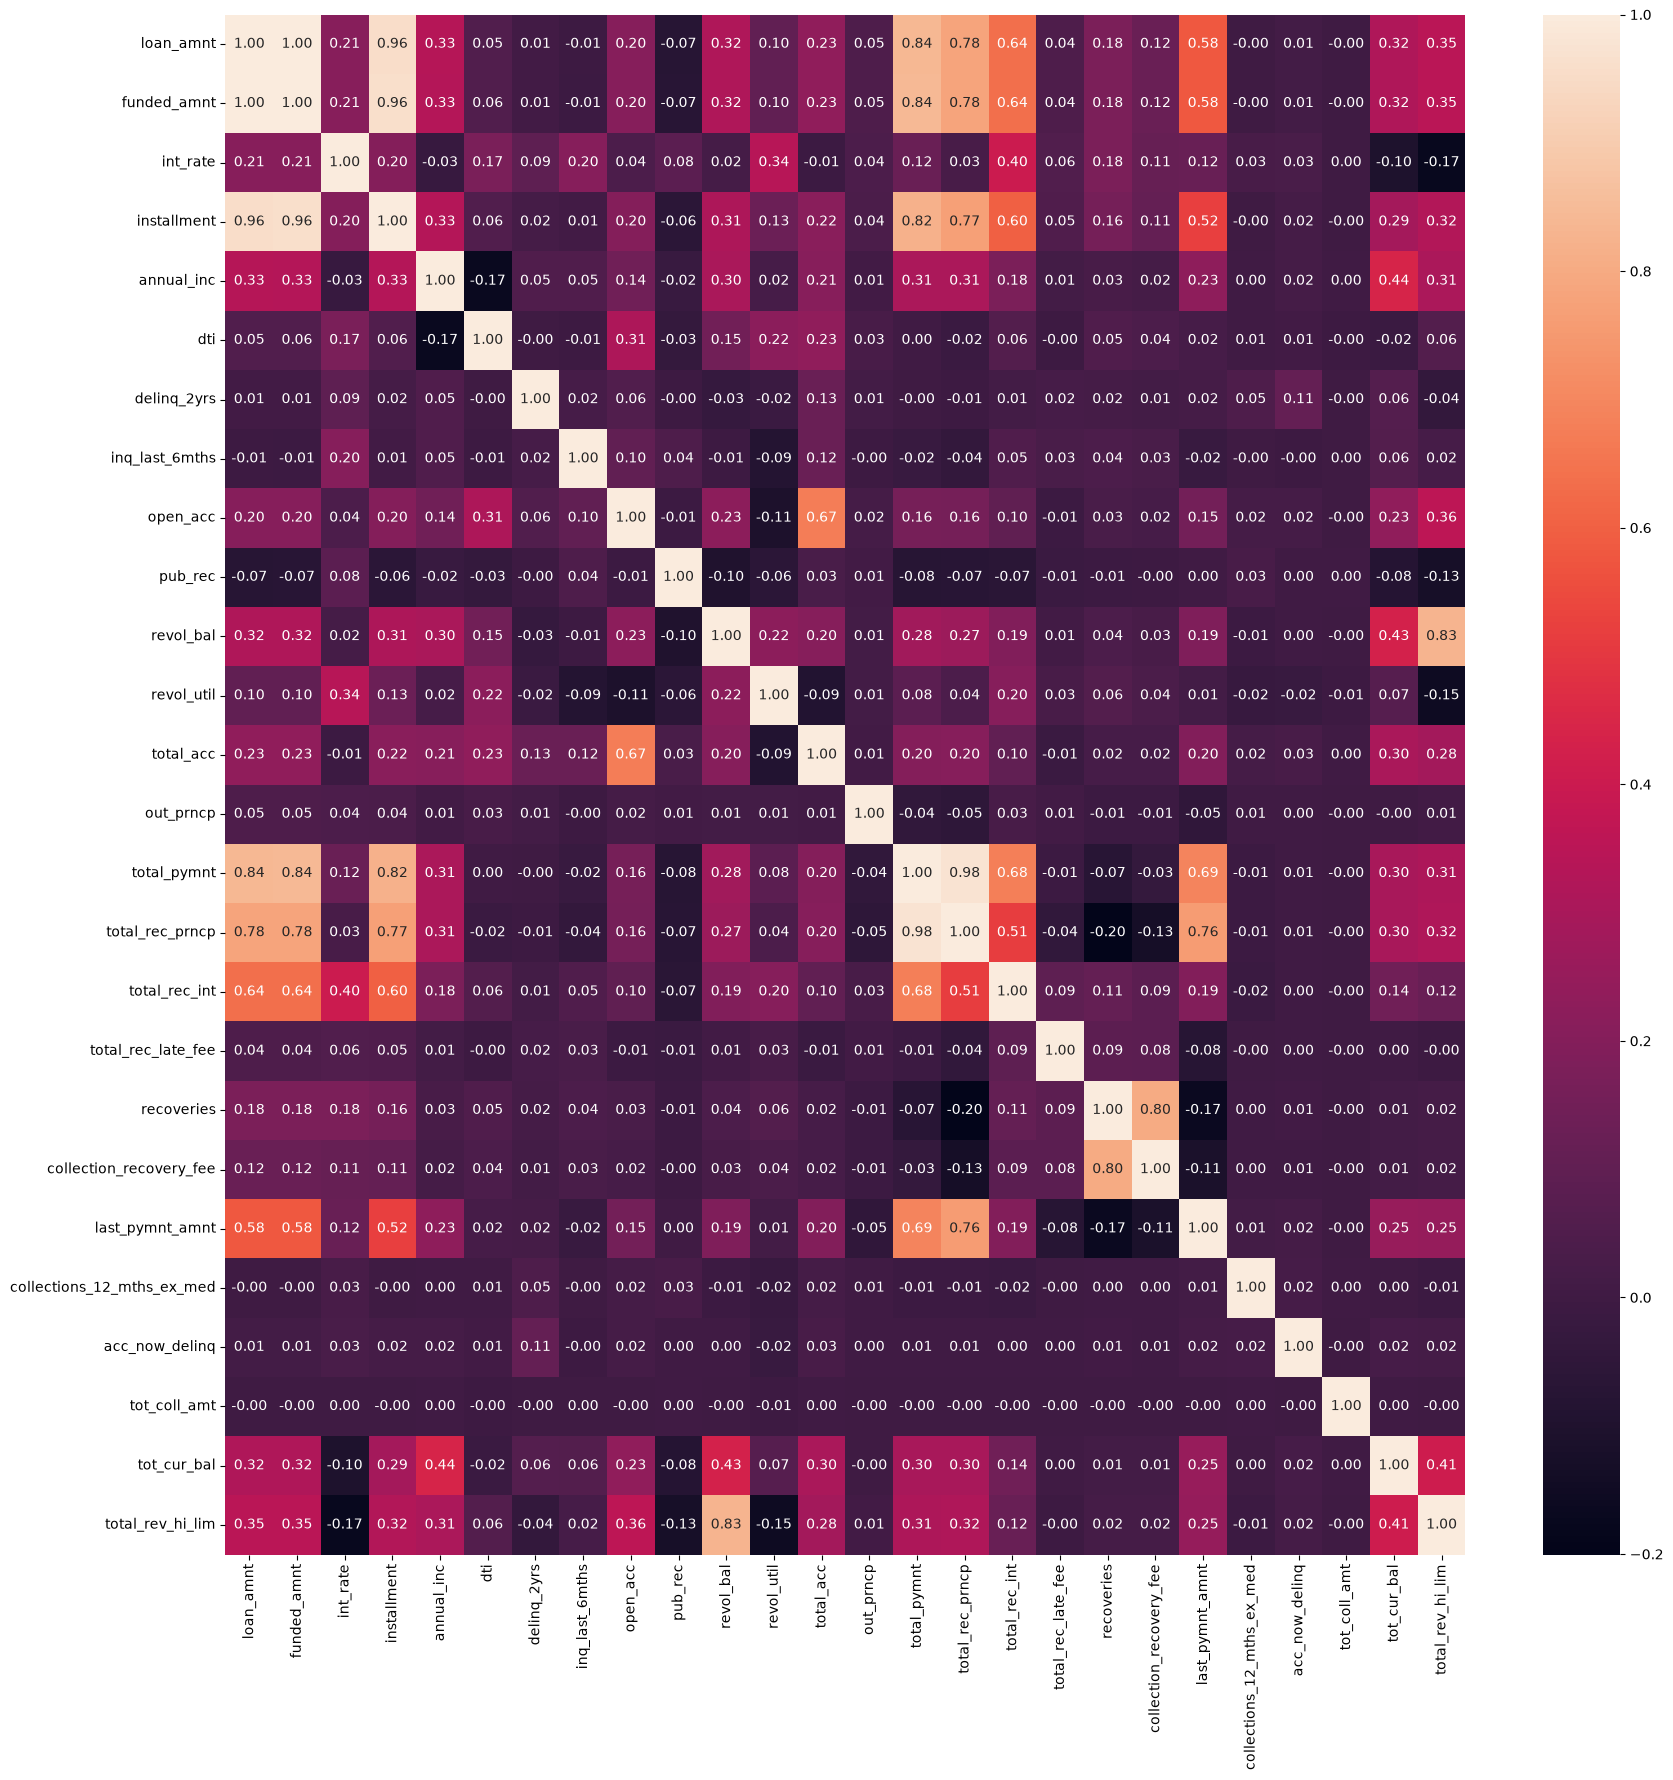

In [219]:
plot.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f")

### analysis of the heatmap
- loan_amnt and funded_amt are same for all the rows,so we only need one column
- installment can be derived from other numeric quantities

<Axes: xlabel='loan_amnt'>

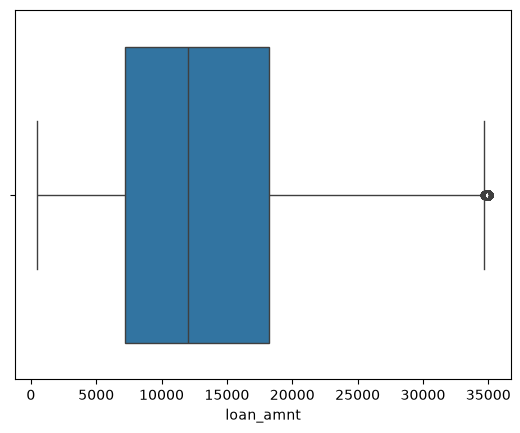

In [220]:
sns.boxplot(data=df,x="loan_amnt")

<Axes: xlabel='funded_amnt'>

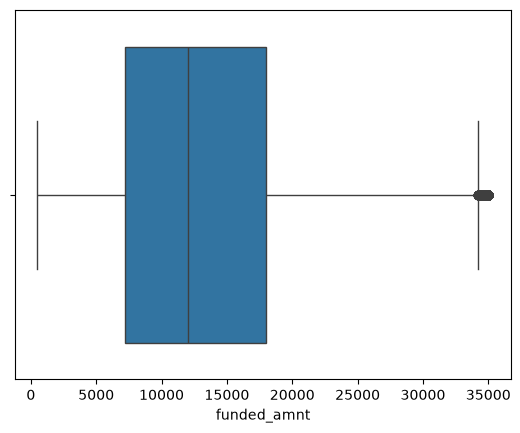

In [221]:
sns.boxplot(data=df,x="funded_amnt")

<Axes: xlabel='term', ylabel='count'>

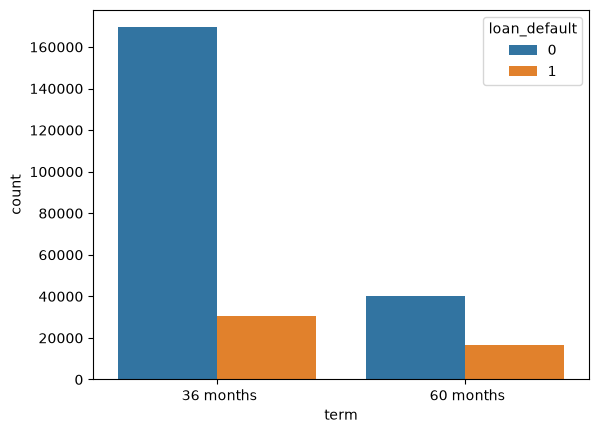

In [222]:
sns.countplot(data=df,x="term",hue="loan_default")

<Axes: xlabel='int_rate', ylabel='Density'>

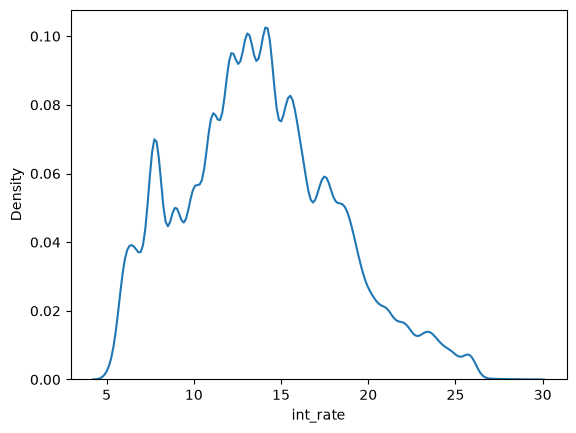

In [223]:
sns.kdeplot(data=df,x="int_rate")

<Axes: xlabel='int_rate', ylabel='Count'>

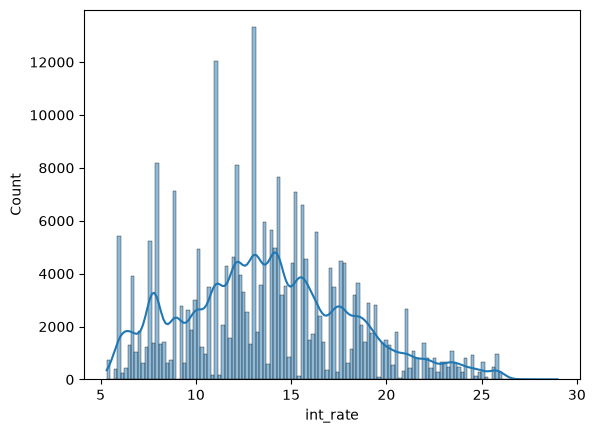

In [224]:
sns.histplot(data=df,x="int_rate",kde=True)

In [225]:
df.sample(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,...,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,loan_default
223232,35000.0,35000.0,36 months,7.90,1095.16,A,A4,"Mythical Metals, Inc.",10+ years,MORTGAGE,...,0.0,0.0,Apr-2015,1098.65,0.0,0.0,NaN,NaN,NaN,0
65649,7125.0,7125.0,36 months,12.99,240.04,B,B4,sipping and receiving,3 years,OWN,...,0.0,0.0,Aug-2015,3559.12,0.0,0.0,0.0,13279.0,15400.0,0
356542,12000.0,12000.0,36 months,11.67,396.69,B,B4,Correctional Officer,10+ years,MORTGAGE,...,0.0,0.0,Jan-2015,10675.37,0.0,0.0,0.0,137204.0,21000.0,0
227250,4500.0,4500.0,36 months,16.29,158.86,D,D1,american red cross,10+ years,MORTGAGE,...,0.0,0.0,Feb-2015,163.16,0.0,0.0,NaN,NaN,NaN,0
1675,18000.0,18000.0,60 months,11.71,397.77,B,B3,Krispy Kreme,4 years,MORTGAGE,...,0.0,0.0,Apr-2014,11311.54,0.0,0.0,NaN,NaN,NaN,0


<Axes: xlabel='grade', ylabel='count'>

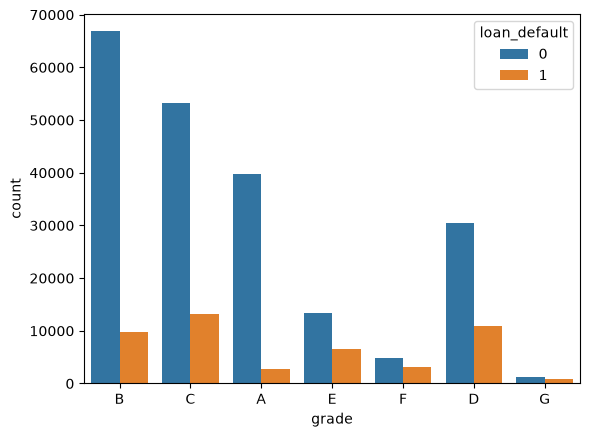

In [226]:
sns.countplot(data=df,x="grade",hue="loan_default")

In [227]:
df["emp_title"].value_counts()

emp_title
Manager                          1959
Teacher                          1927
Supervisor                        863
Registered Nurse                  848
RN                                844
                                 ... 
utility Pre-Craft Trainee           1
JOB OPPORTUNITYSPECIALIST           1
Asst. General Superintendent        1
Gunnery Sgt Instructor              1
Coordinator of RSVP                 1
Name: count, Length: 134758, dtype: int64

### vast categorical column,better be dropped

In [228]:
df.drop('emp_title',axis=1,inplace=True)

<Axes: xlabel='annual_inc'>

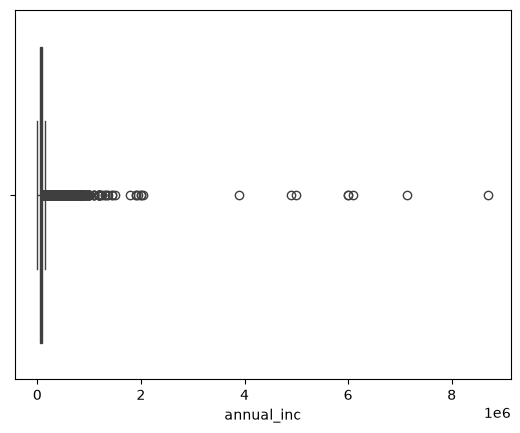

In [230]:
sns.boxplot(data=df,x='annual_inc')

### people across all income_range have taken loan

In [231]:
df['annual_inc'].describe()

count    2.569350e+05
mean     7.249885e+04
std      5.890043e+04
min      1.896000e+03
25%      4.500000e+04
50%      6.200000e+04
75%      8.700000e+04
max      8.706582e+06
Name: annual_inc, dtype: float64

<Axes: xlabel='home_ownership', ylabel='Count'>

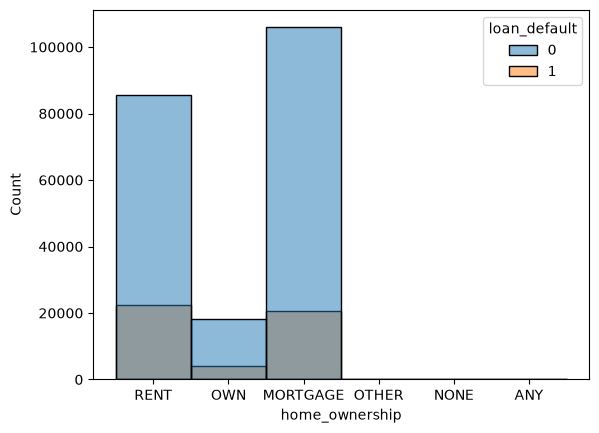

In [232]:
sns.histplot(data=df,x='home_ownership',hue="loan_default")

### people who own home have low default rate,but the numbers of loan are few compare to others

In [233]:
pd.crosstab(df['home_ownership'],df['loan_default'])

loan_default,0,1
home_ownership,,
ANY,1,0
MORTGAGE,105874,20724
NONE,40,8
OTHER,141,38
OWN,18098,4184
RENT,85557,22274


### any,none can be merged into "other"

In [234]:
df['home_ownership']=df['home_ownership'].replace({'ANY':'OTHER','NONE':'OTHER'})

<Axes: xlabel='verification_status', ylabel='Count'>

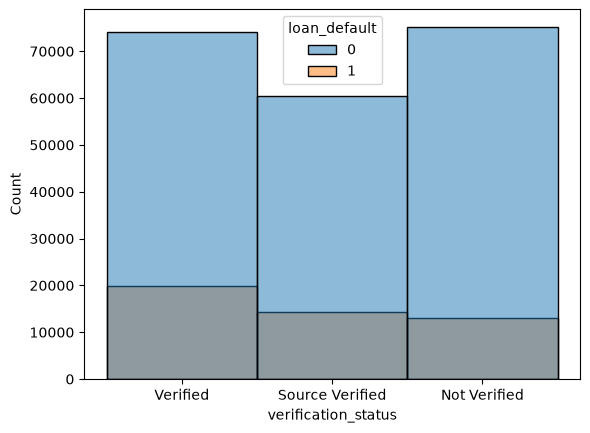

In [235]:
sns.histplot(data=df,x='verification_status',hue='loan_default')

### somewhat equal distribution of all verification_status


In [236]:
df['emp_length'].value_counts()

emp_length
10+ years    77726
2 years      23996
< 1 year     21447
3 years      20750
5 years      18308
1 year       17299
4 years      16468
6 years      14960
7 years      14256
8 years      12029
9 years       9698
Name: count, dtype: int64

<Axes: xlabel='emp_length', ylabel='count'>

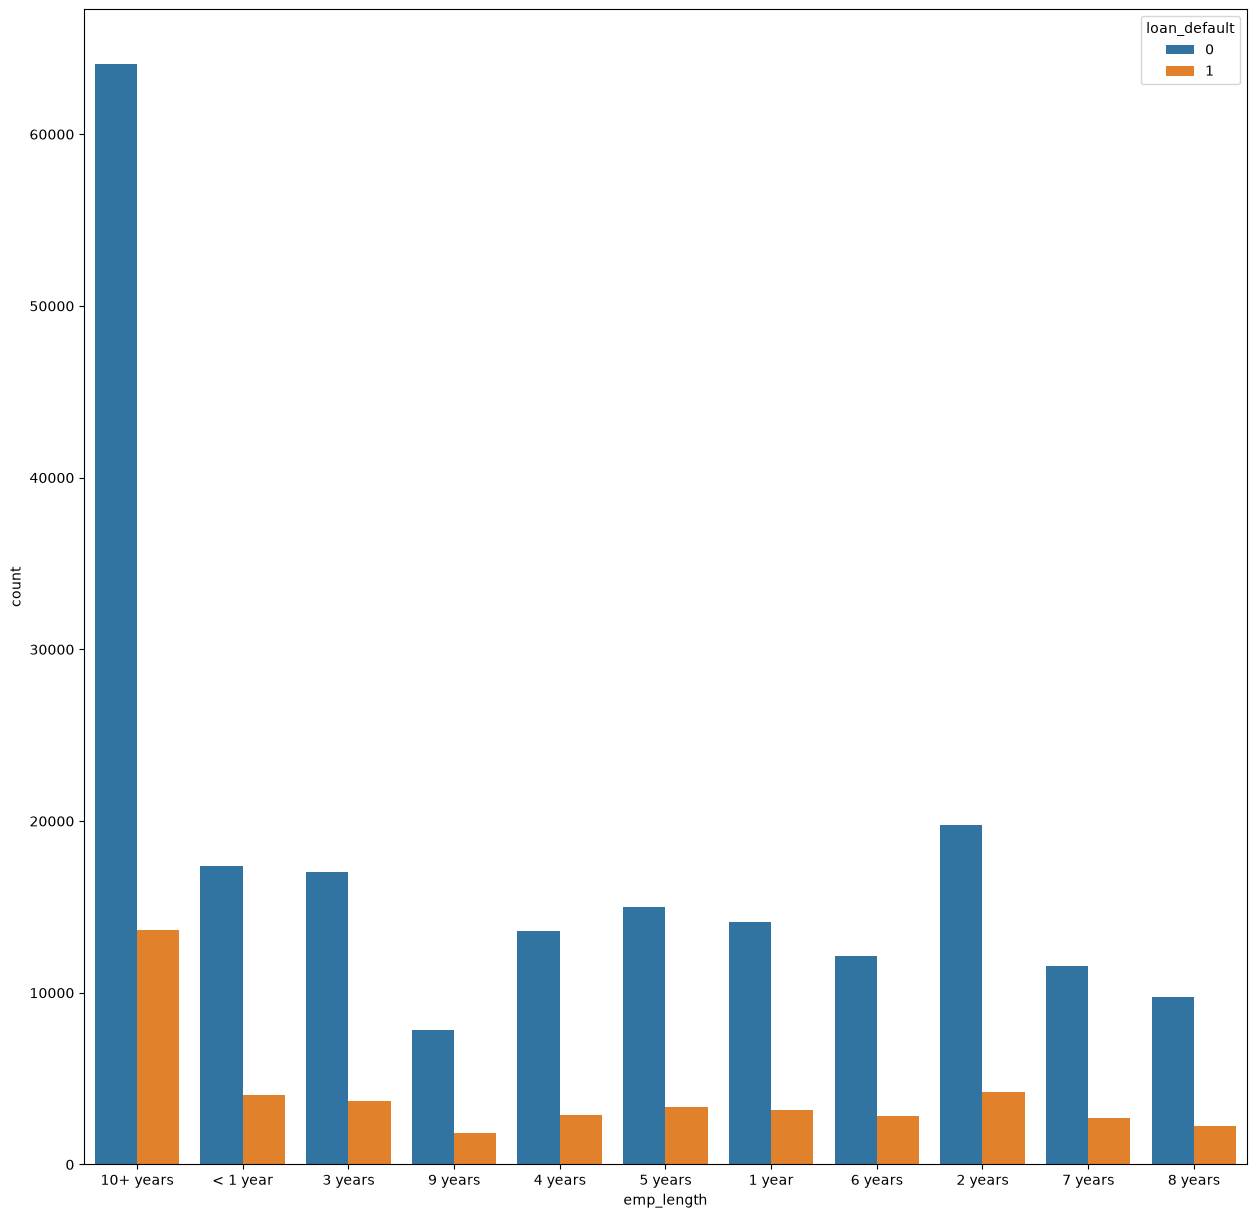

In [237]:
plot.figure(figsize=(15,15))
sns.countplot(data=df,x="emp_length",hue="loan_default")

### 1/4th of the individual are employed for more than 10years. although the loan_default distribution is nearly same across all groups

In [238]:
df['title'].value_counts()

title
Debt consolidation         72768
Credit card refinancing    22990
Debt Consolidation         11175
Home improvement            6787
Other                       6087
                           ...  
finish det payoff              1
Stop the bleeding              1
LoanGetter                     1
Consolidation 01               1
Credit Card/Auto Repair        1
Name: count, Length: 49468, dtype: int64

### this column contains the description for the consideration of loans by individual,hence this column can be dropped

In [239]:
df.drop("title",axis=1,inplace=True)

In [240]:
df['purpose'].value_counts()

purpose
debt_consolidation    150253
credit_card            50649
home_improvement       15190
other                  14766
major_purchase          6402
small_business          4926
car                     3720
medical                 2927
moving                  2085
wedding                 2011
house                   1703
vacation                1615
educational              422
renewable_energy         270
Name: count, dtype: int64

<Axes: xlabel='purpose', ylabel='count'>

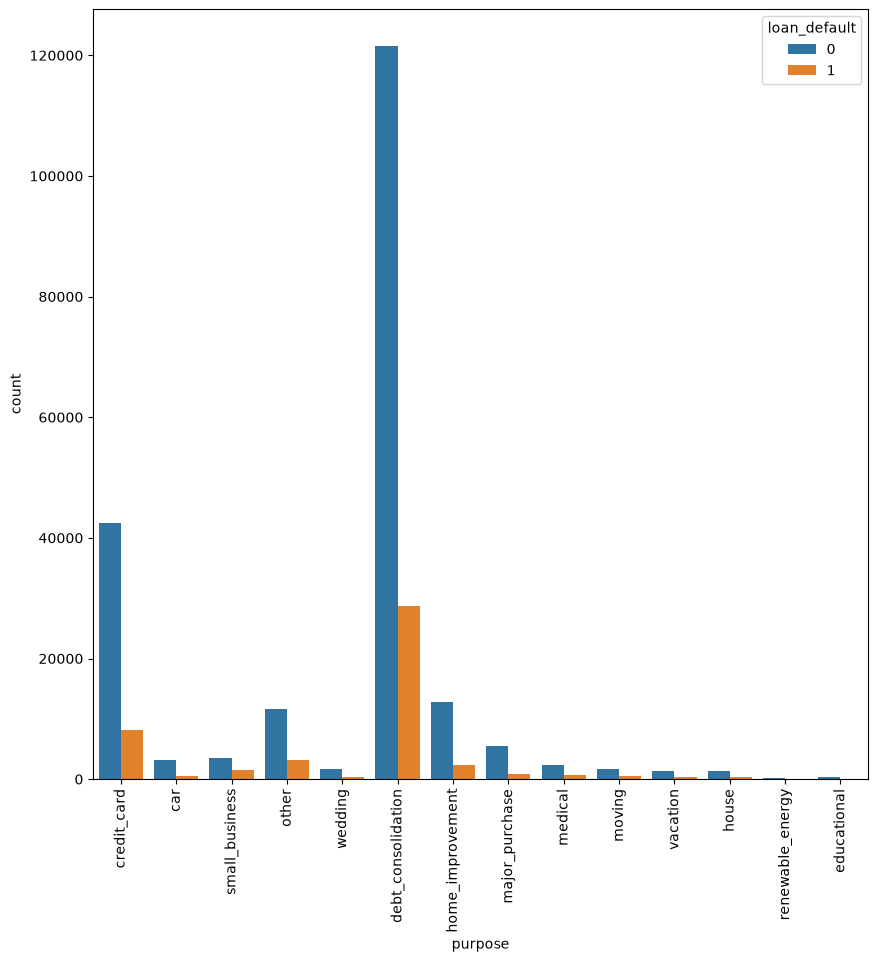

In [241]:
plot.figure(figsize=(10,10))
plot.xticks(rotation=90)
sns.countplot(data=df,x='purpose',hue='loan_default')

### almost 50% of the loans were for debt_consodilation purpose

<Axes: xlabel='dti', ylabel='Density'>

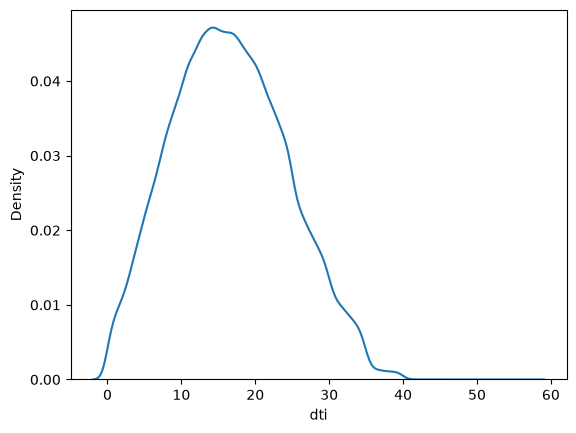

In [242]:
sns.kdeplot(data=df,x='dti')

In [244]:
df['pub_rec'].value_counts()

pub_rec
0.0     225511
1.0      27752
2.0       2583
3.0        687
4.0        204
5.0         94
6.0         39
7.0         19
8.0          8
9.0          5
10.0         5
11.0         1
15.0         1
12.0         1
Name: count, dtype: int64

In [245]:
df[df['pub_rec']>10]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,loan_default
461197,35000.0,35000.0,36 months,16.99,1247.68,D,D1,NaN,RENT,125000.0,...,0.0,0.0,Dec-2014,27696.09,0.0,1.0,0.0,39813.0,60300.0,0
758764,20000.0,20000.0,36 months,7.89,625.72,A,A5,10+ years,OWN,73000.0,...,0.0,0.0,Sep-2015,18723.96,0.0,0.0,0.0,27992.0,21400.0,0
797298,20000.0,20000.0,36 months,14.65,689.89,C,C5,7 years,MORTGAGE,121800.0,...,0.0,0.0,Jul-2015,689.89,0.0,0.0,0.0,97597.0,6100.0,1


<Axes: xlabel='pub_rec', ylabel='Density'>

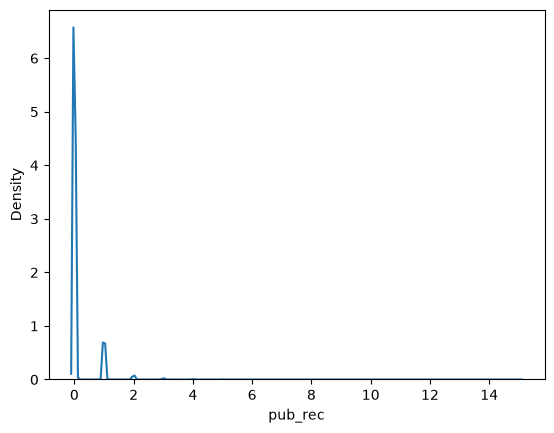

In [246]:
sns.kdeplot(data=df,x='pub_rec')

<Axes: xlabel='pub_rec', ylabel='loan_default'>

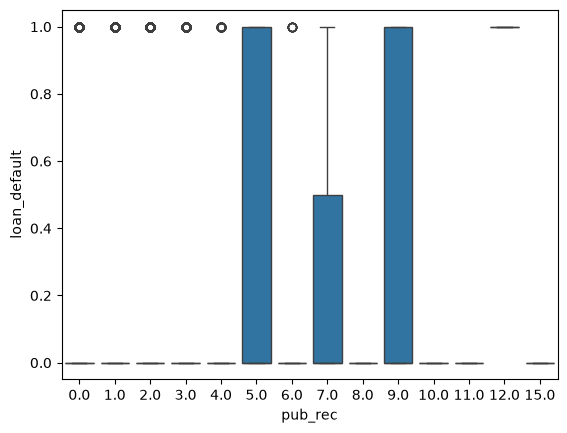

In [247]:
sns.boxplot(x='pub_rec',y='loan_default',data=df)

<Axes: xlabel='total_acc', ylabel='open_acc'>

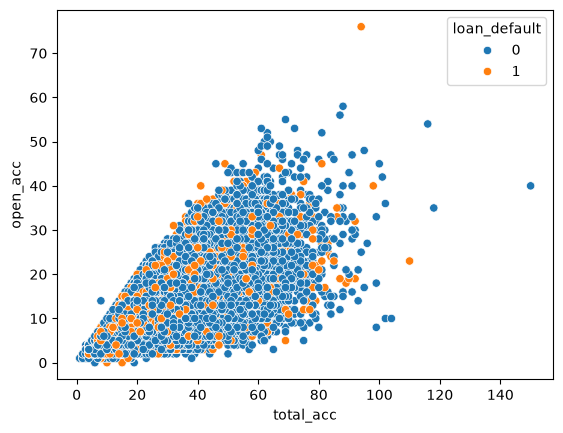

In [248]:
sns.scatterplot(data=df,x='total_acc',y='open_acc',hue='loan_default')

In [249]:
df['earliest_cr_line'].value_counts()

earliest_cr_line
Oct-2000    2143
Oct-1999    2002
Oct-2001    1981
Nov-2000    1957
Aug-2000    1942
            ... 
Nov-1956       1
Aug-2012       1
Oct-2012       1
Jun-1957       1
Aug-1950       1
Name: count, Length: 646, dtype: int64

In [250]:
df['delinq_2yrs'].value_counts()

delinq_2yrs
0.0     215515
1.0      28612
2.0       7902
3.0       2611
4.0       1058
5.0        552
6.0        270
7.0        145
8.0         88
9.0         52
10.0        31
12.0        24
11.0        22
14.0         8
13.0         5
15.0         4
18.0         4
17.0         2
16.0         2
29.0         1
22.0         1
19.0         1
Name: count, dtype: int64

In [251]:
df['inq_last_6mths'].value_counts()

inq_last_6mths
0.0     124680
1.0      73362
2.0      35074
3.0      16264
4.0       4443
5.0       1833
6.0        798
7.0        193
8.0        118
9.0         50
10.0        24
11.0        15
12.0        15
15.0         9
14.0         6
13.0         6
18.0         4
16.0         3
17.0         2
24.0         2
19.0         2
33.0         1
32.0         1
31.0         1
28.0         1
25.0         1
27.0         1
20.0         1
Name: count, dtype: int64

In [252]:
df['acc_now_delinq'].groupby(df['loan_default']).value_counts()

loan_default  acc_now_delinq
0             0.0               209106
              1.0                  549
              2.0                   27
              5.0                    1
              3.0                    1
              4.0                    1
1             0.0                47059
              1.0                  154
              2.0                    9
              3.0                    2
              5.0                    1
Name: count, dtype: int64

In [253]:
df.isnull().sum()

loan_amnt                         0
funded_amnt                       0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_length                    10002
home_ownership                    0
annual_inc                        4
verification_status               0
issue_d                           0
purpose                           0
dti                               0
delinq_2yrs                      29
earliest_cr_line                 29
inq_last_6mths                   29
open_acc                         29
pub_rec                          29
revol_bal                         0
revol_util                      240
total_acc                        29
out_prncp                         0
total_pymnt                       0
total_rec_prncp                   0
total_rec_int                     0
total_rec_late_fee                0
recoveries                  

In [254]:
print(df[df['total_rev_hi_lim'].isna() & (df['revol_bal'] > 0)].shape[0])

65228


In [255]:
df['total_rev_hi_lim'] = df['total_rev_hi_lim'].fillna(
    df.groupby('sub_grade')['total_rev_hi_lim'].transform('median')
)
df['total_rev_hi_lim'] = df['total_rev_hi_lim'].fillna(df['total_rev_hi_lim'].median())

In [256]:
df['tot_coll_amt'] = df['tot_coll_amt'].fillna(0)
df['tot_cur_bal'] = df['tot_cur_bal'].fillna(0)

In [257]:
df.isnull().sum()

loan_amnt                         0
funded_amnt                       0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_length                    10002
home_ownership                    0
annual_inc                        4
verification_status               0
issue_d                           0
purpose                           0
dti                               0
delinq_2yrs                      29
earliest_cr_line                 29
inq_last_6mths                   29
open_acc                         29
pub_rec                          29
revol_bal                         0
revol_util                      240
total_acc                        29
out_prncp                         0
total_pymnt                       0
total_rec_prncp                   0
total_rec_int                     0
total_rec_late_fee                0
recoveries                  

In [258]:
conflict_count = df[df['revol_util'].isna() & (df['revol_bal'] > 0)].shape[0]
print(f"Rows with missing revol_util but active balance: {conflict_count}")

Rows with missing revol_util but active balance: 39


In [259]:
mask = df['revol_util'].isna() & (df['revol_bal'] > 0) & (df['total_rev_hi_lim'] > 0)
df.loc[mask, 'revol_util'] = (df.loc[mask, 'revol_bal'] / df.loc[mask, 'total_rev_hi_lim']) * 100

df['revol_util'] = df['revol_util'].fillna(0)

In [260]:
df.shape

(256939, 37)

In [261]:
df.isnull().sum()

loan_amnt                         0
funded_amnt                       0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_length                    10002
home_ownership                    0
annual_inc                        4
verification_status               0
issue_d                           0
purpose                           0
dti                               0
delinq_2yrs                      29
earliest_cr_line                 29
inq_last_6mths                   29
open_acc                         29
pub_rec                          29
revol_bal                         0
revol_util                        0
total_acc                        29
out_prncp                         0
total_pymnt                       0
total_rec_prncp                   0
total_rec_int                     0
total_rec_late_fee                0
recoveries                  

In [262]:
df = df.dropna(subset=['total_acc']) 

In [264]:
df.shape

(256910, 37)

In [263]:
df.isnull().sum()

loan_amnt                         0
funded_amnt                       0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_length                    10002
home_ownership                    0
annual_inc                        0
verification_status               0
issue_d                           0
purpose                           0
dti                               0
delinq_2yrs                       0
earliest_cr_line                  0
inq_last_6mths                    0
open_acc                          0
pub_rec                           0
revol_bal                         0
revol_util                        0
total_acc                         0
out_prncp                         0
total_pymnt                       0
total_rec_prncp                   0
total_rec_int                     0
total_rec_late_fee                0
recoveries                  

In [265]:
df['collections_12_mths_ex_med'] = df['collections_12_mths_ex_med'].fillna(0)
df['emp_length'] = df['emp_length'].fillna('Unknown')

In [266]:
df.shape

(256910, 37)

In [268]:
df.isnull().sum()

loan_amnt                       0
funded_amnt                     0
term                            0
int_rate                        0
installment                     0
grade                           0
sub_grade                       0
emp_length                      0
home_ownership                  0
annual_inc                      0
verification_status             0
issue_d                         0
purpose                         0
dti                             0
delinq_2yrs                     0
earliest_cr_line                0
inq_last_6mths                  0
open_acc                        0
pub_rec                         0
revol_bal                       0
revol_util                      0
total_acc                       0
out_prncp                       0
total_pymnt                     0
total_rec_prncp                 0
total_rec_int                   0
total_rec_late_fee              0
recoveries                      0
collection_recovery_fee         0
last_pymnt_d  

### Data cleaning and preprocessing done

### Part2: PCA

In [269]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'purpose', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'total_pymnt',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'loan_default'],
      dtype='str')

In [270]:
# one hot encoding
import pandas as pd
cols = ['home_ownership', 'purpose', 'verification_status']
df = pd.get_dummies(df, columns=cols, drop_first=True)

In [271]:
## ordinal encoding
from sklearn.preprocessing import OrdinalEncoder

#term
df['term'] = df['term'].str.strip().map({'36 months': 36, '60 months': 60})

#emp_length
emp_mapping = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'Unknown': -1 
}
df['emp_length'] = df['emp_length'].map(emp_mapping)

#sub_grade
encoder = OrdinalEncoder()
df[['sub_grade']] = encoder.fit_transform(df[['sub_grade']])

In [282]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['earliest_cr_line'] = df['earliest_cr_line'].dt.year


In [285]:
df.shape

(256910, 52)

In [286]:
post_loan_cols= [
    'out_prncp', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 
    'last_pymnt_d', 'last_pymnt_amnt', 'issue_d','grade'
]

X = df.drop(columns=post_loan_cols + ['loan_default'])
y = df['loan_default']
X.shape

(256910, 40)

In [297]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [288]:
X_train.shape

(205528, 40)

In [298]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [299]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=None)


In [317]:
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [304]:
pca.explained_variance_.shape

(40,)

In [309]:
pca.explained_variance_

array([4.62287407e+00, 2.75706023e+00, 1.80839754e+00, 1.68503850e+00,
       1.54230582e+00, 1.46489387e+00, 1.30304306e+00, 1.25393653e+00,
       1.15473856e+00, 1.08291855e+00, 1.05246169e+00, 1.03200041e+00,
       1.02648814e+00, 1.01586286e+00, 1.01129000e+00, 1.00939098e+00,
       1.00879599e+00, 1.00293165e+00, 9.99254030e-01, 9.95522583e-01,
       9.87260505e-01, 9.83906051e-01, 9.78818099e-01, 9.43856259e-01,
       9.36775682e-01, 8.69768575e-01, 8.53883744e-01, 8.15491729e-01,
       7.61499483e-01, 7.02440340e-01, 5.42098896e-01, 4.48702987e-01,
       4.08169793e-01, 3.95609097e-01, 2.81994055e-01, 1.91671188e-01,
       3.23611404e-02, 2.39240446e-02, 1.05810923e-02, 2.17680989e-03])

In [302]:
pca.components_.shape

(40, 40)

In [310]:
pca.explained_variance_ratio_

array([1.15571290e-01, 6.89261703e-02, 4.52097184e-02, 4.21257576e-02,
       3.85574578e-02, 3.66221685e-02, 3.25759180e-02, 3.13482607e-02,
       2.88683235e-02, 2.70728320e-02, 2.63114142e-02, 2.57998847e-02,
       2.56620787e-02, 2.53964478e-02, 2.52821271e-02, 2.52346517e-02,
       2.52197771e-02, 2.50731691e-02, 2.49812292e-02, 2.48879435e-02,
       2.46813925e-02, 2.45975316e-02, 2.44703334e-02, 2.35962917e-02,
       2.34192781e-02, 2.17441086e-02, 2.13469897e-02, 2.03871940e-02,
       1.90373944e-02, 1.75609231e-02, 1.35524065e-02, 1.12175201e-02,
       1.02041952e-02, 9.89017929e-03, 7.04981707e-03, 4.79175639e-03,
       8.09024574e-04, 5.98098204e-04, 2.64526019e-04, 5.44199824e-05])

In [311]:
np.cumsum(pca.explained_variance_ratio_)

array([0.11557129, 0.18449746, 0.22970718, 0.27183294, 0.31039039,
       0.34701256, 0.37958848, 0.41093674, 0.43980506, 0.4668779 ,
       0.49318931, 0.5189892 , 0.54465127, 0.57004772, 0.59532985,
       0.6205645 , 0.64578428, 0.67085745, 0.69583868, 0.72072662,
       0.74540801, 0.77000554, 0.79447588, 0.81807217, 0.84149145,
       0.86323556, 0.88458255, 0.90496974, 0.92400713, 0.94156806,
       0.95512046, 0.96633798, 0.97654218, 0.98643236, 0.99348217,
       0.99827393, 0.99908296, 0.99968105, 0.99994558, 1.        ])

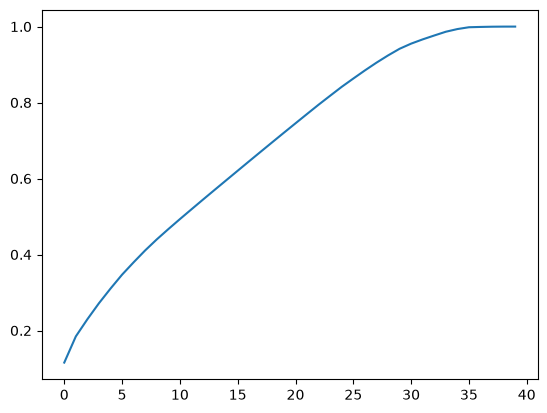

In [318]:
plot.plot(np.cumsum(pca.explained_variance_ratio_))

### we can retain 30 components out of 40 as the cummulative %sum of the explained variance is 94.15

## what Principal components represents
- a principal component is a new feature created by grouping original features based on comibned variance and co-variance
- dimensionality reduction is useful for large datasets,as it reduces the features for training,lowering computation time and reducing the chances of model overfitting.